# Lista de Exercícios C13 — Sintonia de Controladores PID
### Métodos de Smith, Ziegler-Nichols (malha aberta), CHR e IMC



In [4]:
import numpy as np
import control as cnt
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4.5)

def montar_malha_fechada(K, tau, theta, kp, Ti, Td, n_pade=10):
    """Planta FOPDT + atraso (Padé) + controlador PID paralelo, com realimentação unitária."""
    num = np.array([K])
    den = np.array([tau, 1])
    H = cnt.tf(num, den)

    num_pade, den_pade = cnt.pade(theta, n_pade)
    H_pade = cnt.tf(num_pade, den_pade)

    Hkp = cnt.tf([kp], [1])
    Hki = cnt.tf([kp], [Ti, 0])
    Hkd = cnt.tf([kp*Td, 0], [1])

    Hctrl = cnt.parallel(cnt.parallel(Hkp, Hki), Hkd)

    Hs = cnt.series(H, H_pade)
    Hdel = cnt.series(Hs, Hctrl)
    Hcl = cnt.feedback(Hdel, 1)
    return Hcl

def resposta_degrau(K, tau, theta, kp, Ti, Td, amplitude=1.0, t_final=None, n_pade=10):
    if t_final is None:
        t_final = max(40, 15*(tau+theta))
    Hcl = montar_malha_fechada(K, tau, theta, kp, Ti, Td, n_pade)
    t = np.linspace(0, t_final, 600)
    t, y = cnt.step_response(Hcl, t)
    return t, amplitude*y

def tabela_parametros(linhas):
    print(f"{'Método':<24}{'Kp':>10}{'Ti [s]':>12}{'Td [s]':>12}")
    print("-"*58)
    for nome, kp, ti, td in linhas:
        print(f"{nome:<24}{kp:>10.4f}{ti:>12.4f}{td:>12.4f}")

def zn_malha_aberta(K, tau, theta):
    kp = 1.2*tau/(K*theta)
    ti = 2*theta
    td = 0.5*theta
    return kp, ti, td

def chr_0_sobrevalor(K, tau, theta):
    # CHR, resposta ao setpoint, 0% de sobrevalor (overshoot)
    kp = 0.6*tau/(K*theta)
    ti = tau
    td = 0.5*theta
    return kp, ti, td

def chr_20_sobrevalor(K, tau, theta):
    # CHR, resposta ao setpoint, 20% de sobrevalor (overshoot)
    kp = 0.95*tau/(K*theta)
    ti = 1.4*tau
    td = 0.47*theta
    return kp, ti, td

def imc_pid(K, tau, theta, lam):
    # IMC-PID (Rivera, Morari & Skogestad, 1986) com aproximação de Padé de 1ª ordem para o atraso
    kp = (tau + theta/2) / (K*(lam + theta/2))
    ti = tau + theta/2
    td = (tau*theta) / (2*tau + theta)
    return kp, ti, td


---
## Questão 1 — Estufa agrícola inteligente

Degrau: Δu = 0,20 (20% do duty cycle) → ΔT = 34 − 22 = 12 °C

Pontos da curva de reação (método de Smith):
- t₁ (28,3%) = 15 s
- t₂ (63,2%) = 42 s

### a) Identificação pelo método de Smith

Fórmulas do método de Smith (dois pontos, 28,3% e 63,2% do valor final):

$$\tau = 1{,}5\,(t_2 - t_1) \qquad \theta = t_2 - \tau$$

$$K = \frac{\Delta T}{\Delta u}$$


In [5]:
t1, t2 = 15, 42
delta_T = 34 - 22
delta_u = 0.20

tau_1 = 1.5*(t2 - t1)
theta_1 = t2 - tau_1
K_1 = delta_T/delta_u

print(f"K     = {K_1:.2f}  [°C / (fração de duty cycle)]")
print(f"tau   = {tau_1:.2f} s")
print(f"theta = {theta_1:.2f} s")
print()
print(f"G(s) = {K_1:.1f} * e^(-{theta_1:.1f}s) / ({tau_1:.1f}s + 1)")


K     = 60.00  [°C / (fração de duty cycle)]
tau   = 40.50 s
theta = 1.50 s

G(s) = 60.0 * e^(-1.5s) / (40.5s + 1)


### b) Kp, Ti e Td — Ziegler-Nichols (malha aberta), CHR sem sobrevalor e IMC

Para o IMC é necessário escolher a constante de tempo de malha fechada λ. Como o enunciado não fixa
um valor aqui (isso só é pedido explicitamente na Questão 5, com esta mesma planta), adota-se
**λ = θ**, uma escolha padrão e intermediária entre agressividade e robustez (Ms ≈ 1,7), servindo de
referência de comparação com os métodos clássicos.


In [6]:
kp_zn, ti_zn, td_zn = zn_malha_aberta(K_1, tau_1, theta_1)
kp_chr, ti_chr, td_chr = chr_0_sobrevalor(K_1, tau_1, theta_1)

lam_1 = theta_1  # escolha adotada para o IMC neste item
kp_imc, ti_imc, td_imc = imc_pid(K_1, tau_1, theta_1, lam_1)

tabela_parametros([
    ("Ziegler-Nichols (MA)", kp_zn, ti_zn, td_zn),
    ("CHR sem sobrevalor", kp_chr, ti_chr, td_chr),
    (f"IMC (lambda=theta)", kp_imc, ti_imc, td_imc),
])


Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
Ziegler-Nichols (MA)        0.5400      3.0000      0.7500
CHR sem sobrevalor          0.2700     40.5000      0.7500
IMC (lambda=theta)          0.3056     41.2500      0.7364


### c) Resposta ao degrau unitário

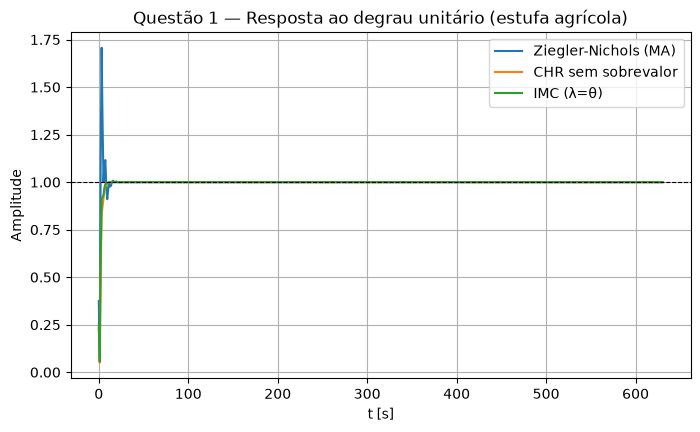

In [7]:
t_zn, y_zn = resposta_degrau(K_1, tau_1, theta_1, kp_zn, ti_zn, td_zn, amplitude=1.0)
t_chr, y_chr = resposta_degrau(K_1, tau_1, theta_1, kp_chr, ti_chr, td_chr, amplitude=1.0)
t_imc, y_imc = resposta_degrau(K_1, tau_1, theta_1, kp_imc, ti_imc, td_imc, amplitude=1.0)

plt.figure()
plt.plot(t_zn, y_zn, label="Ziegler-Nichols (MA)")
plt.plot(t_chr, y_chr, label="CHR sem sobrevalor")
plt.plot(t_imc, y_imc, label="IMC (λ=θ)")
plt.axhline(1.0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Questão 1 — Resposta ao degrau unitário (estufa agrícola)")
plt.legend()
plt.grid()
plt.show()


### d) Análise comparativa

- **Ziegler-Nichols (malha aberta)** produz o ganho mais alto dos três (Kp ≈ 0,54) e o menor Ti
  (Ti = 2θ = 3 s). É o método historicamente mais agressivo: tende a gerar sobrevalor considerável e
  resposta oscilatória, pois foi originalmente concebido para uma margem de fase menor (mais rápida,
  porém menos robusta a erros de modelagem).
- **CHR sem sobrevalor** usa um Kp bem menor (≈ 0,27) e um Ti igual à própria constante de tempo do
  processo (Ti = τ = 40,5 s). Por construção, é o mais conservador dos três: prioriza eliminar
  qualquer ultrapassagem do valor final, à custa de uma resposta mais lenta — adequado quando
  overshoot é indesejável (ex.: não se quer superaquecer a estufa).
- **IMC (λ=θ)** fica numa posição intermediária entre os dois anteriores (Kp ≈ 0,31, Ti ≈ 41,25 s),
  com a vantagem de ter o parâmetro de ajuste λ explícito: aumentando λ a resposta fica ainda mais
  lenta e robusta; diminuindo λ (até o limite λ→0) a resposta se aproxima da agressividade do
  Ziegler-Nichols.
- Em termos de Td, os três métodos ficam próximos (entre 0,74 s e 0,75 s), já que o atraso de
  transporte (θ = 1,5 s) é pequeno frente à constante de tempo — o termo derivativo tem, portanto,
  peso pequeno na dinâmica global.
- Para uma estufa agrícola (processo lento, tolerante a pequenas variações, mas sensível a
  ultrapassar a temperatura-alvo por longos períodos), o CHR sem sobrevalor ou um IMC com λ maior
  seriam as escolhas mais seguras; o ZN aberto serve melhor como ponto de partida a ser refinado.


---
## Questão 2 — Por que ZN e CHR não são usados como ajuste final?

Os métodos de Ziegler-Nichols e CHR foram desenvolvidos a partir de curvas de reação idealizadas de
processos de 1ª ordem com atraso (FOPDT), assumindo um modelo simplificado e sem considerar
explicitamente robustez a incertezas de modelagem, ruído de medição, saturação do atuador ou
dinâmicas de ordem superior presentes na planta real. Eles fornecem fórmulas fechadas e rápidas de
aplicar, mas:

- tendem a gerar respostas com sobrevalor e oscilações consideráveis (especialmente o ZN, pensado
  para 1/4 de decaimento de amplitude);
- não levam em conta explicitamente margens de estabilidade/robustez (margem de ganho e de fase),
  nem o compromisso entre desempenho e robustez que uma malha industrial real exige;
- assumem que o modelo identificado (K, τ, θ) representa bem a planta em toda a faixa de operação,
  o que raramente é verdade em processos não lineares ou variantes no tempo.

Por isso, na prática eles são usados como **ponto de partida**: fornecem uma estimativa inicial
razoável dos parâmetros do PID, que depois é refinada por ajuste fino manual, métodos baseados em
modelo mais robustos (como IMC, com o parâmetro λ ajustável) ou otimização/autotuning, até que a
malha atenda aos critérios de desempenho e robustez exigidos pelo processo real.


---
## Questão 3 — Ziegler-Nichols (malha aberta) para dois sistemas IoT

### a) Irrigação automatizada — G(s) = 2,5·e^(−4s) / (20s + 1)
### b) Esteira transportadora — G(s) = 1,8·e^(−0,8s) / (3s + 1)


In [8]:
K_3a, tau_3a, theta_3a = 2.5, 20, 4
K_3b, tau_3b, theta_3b = 1.8, 3, 0.8

kp_3a, ti_3a, td_3a = zn_malha_aberta(K_3a, tau_3a, theta_3a)
kp_3b, ti_3b, td_3b = zn_malha_aberta(K_3b, tau_3b, theta_3b)

print("a) Irrigação automatizada:")
tabela_parametros([("Ziegler-Nichols (MA)", kp_3a, ti_3a, td_3a)])
print(f"   theta = {theta_3a} s   |   Ti = {ti_3a} s   |   Ti/theta = {ti_3a/theta_3a:.2f}")

print()
print("b) Esteira transportadora:")
tabela_parametros([("Ziegler-Nichols (MA)", kp_3b, ti_3b, td_3b)])
print(f"   theta = {theta_3b} s   |   Ti = {ti_3b} s   |   Ti/theta = {ti_3b/theta_3b:.2f}")

print()
atraso_wifi = 0.3
print(f"Atraso adicional Wi-Fi de {atraso_wifi} s como fração de theta:")
print(f"   Irrigação : {atraso_wifi/theta_3a*100:.1f}% de theta   |  {atraso_wifi/ti_3a*100:.1f}% de Ti")
print(f"   Esteira   : {atraso_wifi/theta_3b*100:.1f}% de theta  |  {atraso_wifi/ti_3b*100:.1f}% de Ti")


a) Irrigação automatizada:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
Ziegler-Nichols (MA)        2.4000      8.0000      2.0000
   theta = 4 s   |   Ti = 8 s   |   Ti/theta = 2.00

b) Esteira transportadora:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
Ziegler-Nichols (MA)        2.5000      1.6000      0.4000
   theta = 0.8 s   |   Ti = 1.6 s   |   Ti/theta = 2.00

Atraso adicional Wi-Fi de 0.3 s como fração de theta:
   Irrigação : 7.5% de theta   |  3.8% de Ti
   Esteira   : 37.5% de theta  |  18.7% de Ti


**Comparação de Ti com o tempo morto θ:** pela fórmula de Ziegler-Nichols (malha aberta), Ti = 2θ
sempre — ou seja, a razão Ti/θ é igual a 2 nos dois sistemas por construção do método. A diferença
relevante está na **magnitude absoluta** de θ e Ti em cada caso: na irrigação, θ = 4 s e Ti = 8 s; na
esteira, θ = 0,8 s e Ti = 1,6 s.

**Qual sistema é mais sensível a um atraso adicional de 300 ms de Wi-Fi?**
A esteira transportadora é claramente mais sensível. Um atraso extra de 300 ms representa cerca de
**37,5% do seu próprio tempo morto** (0,8 s) e quase **19% do seu Ti** (1,6 s) — uma perturbação
proporcionalmente enorme na dinâmica de malha fechada, que pode comprometer significativamente a
estabilidade e a margem de fase do sistema. Já na irrigação, os mesmos 300 ms equivalem a apenas
**7,5% do tempo morto** (4 s) e **3,75% do Ti** (8 s), um acréscimo proporcionalmente pequeno diante
da dinâmica muito mais lenta do processo. Em suma: quanto mais rápido o processo (menores τ e θ),
maior o impacto relativo de um atraso de comunicação fixo — por isso a esteira, com dinâmica muito
mais rápida, é a mais vulnerável ao atraso Wi-Fi.


---
## Questão 4 — Armário de rede (data center IoT)

G(s) = 1,5·e^(−1s) / (6s + 1)


In [9]:
K_4, tau_4, theta_4 = 1.5, 6, 1

kp_4a, ti_4a, td_4a = chr_0_sobrevalor(K_4, tau_4, theta_4)
kp_4b, ti_4b, td_4b = chr_20_sobrevalor(K_4, tau_4, theta_4)

print("a) CHR sem sobrevalor:")
tabela_parametros([("CHR 0% sobrevalor", kp_4a, ti_4a, td_4a)])
print()
print("b) CHR com 20% de sobrevalor:")
tabela_parametros([("CHR 20% sobrevalor", kp_4b, ti_4b, td_4b)])


a) CHR sem sobrevalor:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
CHR 0% sobrevalor           2.4000      6.0000      0.5000

b) CHR com 20% de sobrevalor:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
CHR 20% sobrevalor          3.8000      8.4000      0.4700


### c) Resposta a um degrau de valor 15

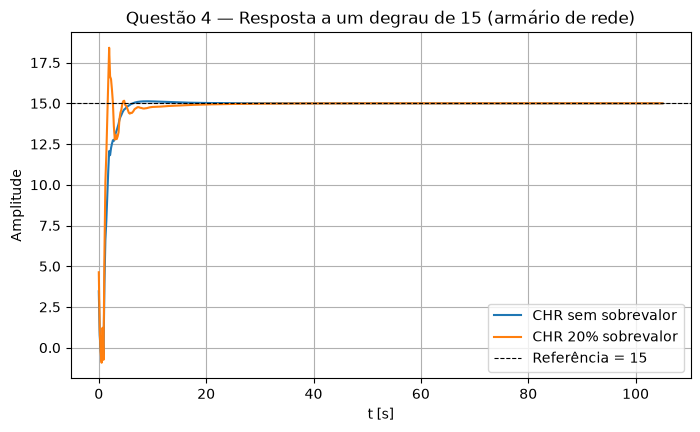

Sobrevalor observado (0%%):  0.83 %%
Sobrevalor observado (20%%): 22.74 %%


In [10]:
t_4a, y_4a = resposta_degrau(K_4, tau_4, theta_4, kp_4a, ti_4a, td_4a, amplitude=15)
t_4b, y_4b = resposta_degrau(K_4, tau_4, theta_4, kp_4b, ti_4b, td_4b, amplitude=15)

plt.figure()
plt.plot(t_4a, y_4a, label="CHR sem sobrevalor")
plt.plot(t_4b, y_4b, label="CHR 20% sobrevalor")
plt.axhline(15, color='k', linewidth=0.8, linestyle='--', label="Referência = 15")
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Questão 4 — Resposta a um degrau de 15 (armário de rede)")
plt.legend()
plt.grid()
plt.show()

print(f"Sobrevalor observado (0%%):  {(max(y_4a)-15)/15*100:.2f} %%")
print(f"Sobrevalor observado (20%%): {(max(y_4b)-15)/15*100:.2f} %%")


### d) Comparação dos dois Kp e recomendação

O ganho do ajuste CHR com 20% de sobrevalor (Kp ≈ 3,80) é bem maior que o do ajuste sem sobrevalor
(Kp ≈ 2,40) — cerca de 58% maior. Um Kp maior torna a resposta mais rápida, mas ao custo de permitir
que a temperatura ultrapasse o valor-alvo antes de se estabilizar.

Para um **data center**, onde ultrapassar a temperatura-alvo — mesmo que temporariamente — pode
acelerar o desgaste dos equipamentos, a recomendação é usar o ajuste **CHR sem sobrevalor**
(item a). Ele evita qualquer excursão acima do setpoint, trocando velocidade de resposta por
segurança térmica, o que é a prioridade correta neste tipo de aplicação — diferentemente de um
processo onde uma resposta mais rápida compensaria o risco de um pequeno overshoot.


---
## Questão 5 — Estufa agrícola (mesma planta do Bloco 0 / Questão 1)

K = 60, τ = 40,5 s, θ = 1,5 s


In [11]:
K_5, tau_5, theta_5 = 60, 40.5, 1.5

lam_5a = 1.5*theta_5
lam_5b = 4*theta_5

kp_5a, ti_5a, td_5a = imc_pid(K_5, tau_5, theta_5, lam_5a)
kp_5b, ti_5b, td_5b = imc_pid(K_5, tau_5, theta_5, lam_5b)

print(f"a) IMC com lambda = 1.5*theta = {lam_5a} s:")
tabela_parametros([("IMC (lambda=1.5*theta)", kp_5a, ti_5a, td_5a)])
print()
print(f"b) IMC com lambda = 4*theta = {lam_5b} s:")
tabela_parametros([("IMC (lambda=4*theta)", kp_5b, ti_5b, td_5b)])


a) IMC com lambda = 1.5*theta = 2.25 s:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
IMC (lambda=1.5*theta)      0.2292     41.2500      0.7364

b) IMC com lambda = 4*theta = 6.0 s:
Método                          Kp      Ti [s]      Td [s]
----------------------------------------------------------
IMC (lambda=4*theta)        0.1019     41.2500      0.7364


### c) Resposta a um degrau de valor 20

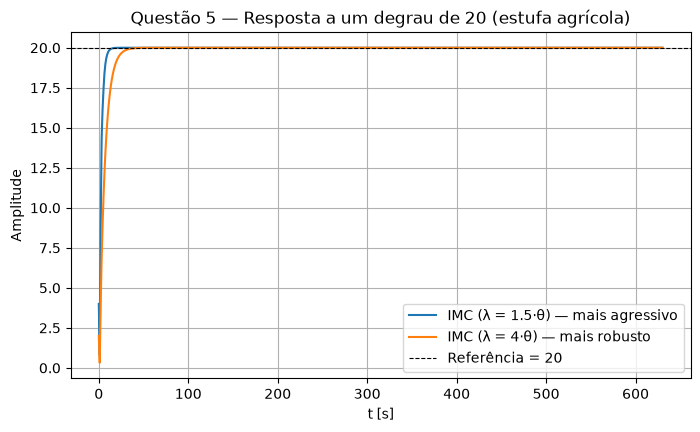

Sobrevalor (lambda=1.5*theta): 0.00 %
Sobrevalor (lambda=4*theta):   0.00 %


In [12]:
t_5a, y_5a = resposta_degrau(K_5, tau_5, theta_5, kp_5a, ti_5a, td_5a, amplitude=20)
t_5b, y_5b = resposta_degrau(K_5, tau_5, theta_5, kp_5b, ti_5b, td_5b, amplitude=20)

plt.figure()
plt.plot(t_5a, y_5a, label="IMC (λ = 1.5·θ) — mais agressivo")
plt.plot(t_5b, y_5b, label="IMC (λ = 4·θ) — mais robusto")
plt.axhline(20, color='k', linewidth=0.8, linestyle='--', label="Referência = 20")
plt.xlabel("t [s]")
plt.ylabel("Amplitude")
plt.title("Questão 5 — Resposta a um degrau de 20 (estufa agrícola)")
plt.legend()
plt.grid()
plt.show()

print(f"Sobrevalor (lambda=1.5*theta): {(max(y_5a)-20)/20*100:.2f} %")
print(f"Sobrevalor (lambda=4*theta):   {(max(y_5b)-20)/20*100:.2f} %")


### d) Relação entre λ, velocidade de resposta e robustez

O parâmetro λ do IMC é, por definição, aproximadamente a constante de tempo de malha fechada
desejada: quanto **menor** λ, mais agressivo o controlador (Kp maior — compare Kp ≈ 0,229 para
λ=1,5θ contra Kp ≈ 0,102 para λ=4θ), resultando em resposta **mais rápida**, porém **menos robusta**
a erros de modelagem, ruído de medição e variações da planta — o sistema fica mais próximo do limite
de estabilidade e mais sensível a qualquer atraso ou dinâmica não modelada. Já um λ **maior** produz
um Kp menor, resposta **mais lenta**, mas com margens de estabilidade maiores e menor sensibilidade
a incertezas — ou seja, mais **robustez**.

Ti e Td não dependem de λ nesta formulação (dependem apenas de τ e θ), portanto λ atua
essencialmente como um "botão único" que desloca o compromisso velocidade × robustez através do
ganho proporcional.

Para uma estufa sujeita a **rajadas de vento que abrem e fecham repetidamente as telas de
ventilação**, essas rajadas são perturbações rápidas e frequentes. Um controlador muito agressivo
(λ pequeno) reagiria fortemente a cada rajada, gerando um sinal de controle "nervoso" — comandos
excessivos e oscilantes no aquecedor/ventilação, com desgaste mecânico do atuador e possível
amplificação de ruído. Por isso, a escolha mais adequada aqui é um **λ maior (λ = 4θ)**: a resposta
fica mais lenta perante o setpoint, mas o controlador filtra melhor as perturbações rápidas e
repetitivas, resultando em uma ação de controle mais suave e um sistema mais robusto às oscilações
de vento — o que compensa a perda de velocidade de resposta.
